In [1]:
# ============================================
# Step 1: Install and Import
# ============================================
!pip install wrds

import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================
# Step 2: Connect WRDS once
# ============================================

try:
    db = wrds.Connection()
    print("Connected to WRDS")
except Exception as e:
    print(f"ERROR: Cannot connect to WRDS: {e}")
    db = None

Enter your WRDS username [glori]: skylarrrzhang
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\glori\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Connected to WRDS


In [3]:
# ============================================
# Step 3: User selects mode
# ============================================

print("Select Mode:")
print("A = Compare different industries")
print("B = Compare stocks in same industry")

mode = input("Enter A or B: ").strip().upper()

if mode == "A":
    stocks_input = input("Enter stock tickers (comma separated, e.g. AAPL,TSLA,JPM,KO): ")
elif mode == "B":
    stocks_input = input("Enter stocks in SAME industry (e.g. MSFT,GOOG,NVDA): ")
else:
    print("Invalid mode, default to A")
    stocks_input = "AAPL,TSLA,JPM,KO"
    
stocks = [s.strip().upper() for s in stocks_input.split(",")]

Select Mode:
A = Compare different industries
B = Compare stocks in same industry


Enter A or B:  A
Enter stock tickers (comma separated, e.g. AAPL,TSLA,JPM,KO):  AAPL,TSLA,JPM,KO


Enter start date (YYYY-MM-DD):  2022-01-01


<Figure size 640x480 with 0 Axes>

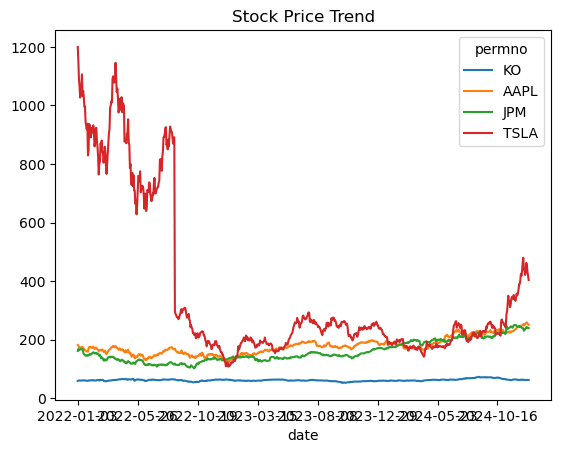

<Figure size 640x480 with 0 Axes>

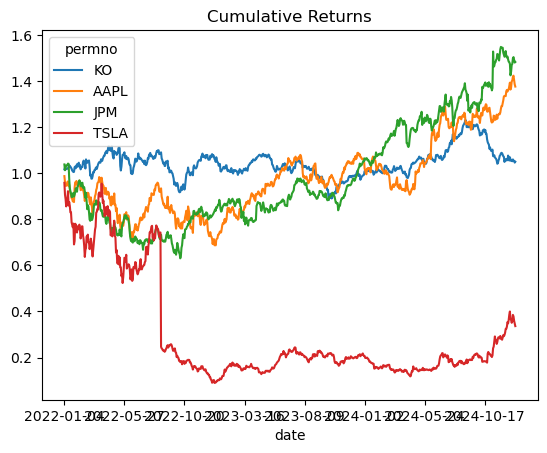

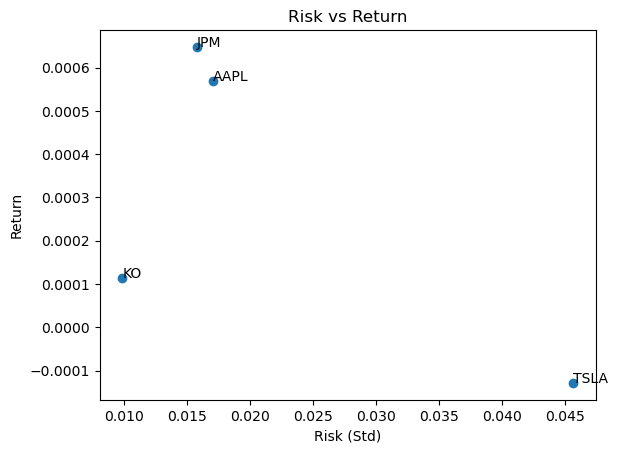

<Figure size 640x480 with 0 Axes>

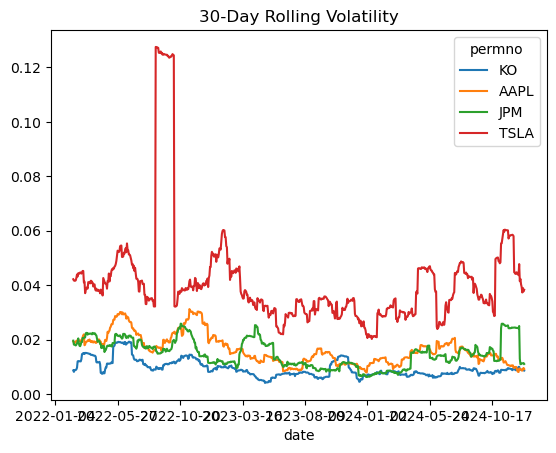

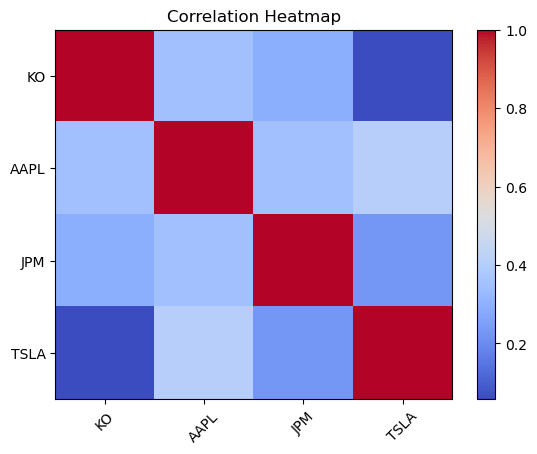


Sharpe Ratio Ranking:
permno
JPM      0.04102
AAPL    0.033369
KO      0.011518
TSLA   -0.002816
dtype: Float64


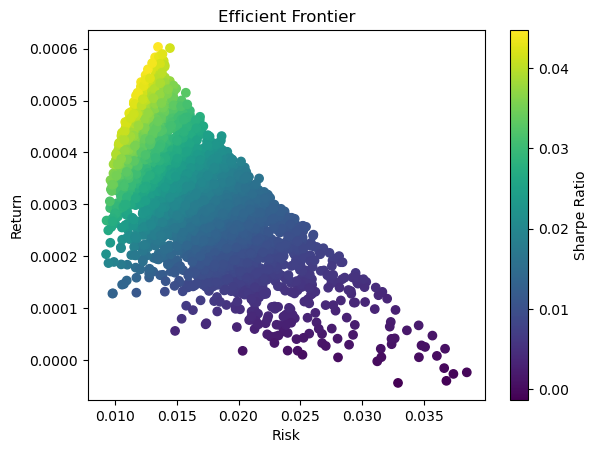

In [ ]:
# ============================================
# Step 4: Analysis Loop (Enhanced Version)
# ============================================

while db is not None:

    start_date = input("Enter start date (YYYY-MM-DD): ").strip()

    try:
        pd.to_datetime(start_date)
    except:
        print("Invalid date format")
        continue

    try:
        ticker_str = ",".join([f"'{s}'" for s in stocks])

        query_permno = f"""
        SELECT ticker, permno
        FROM crsp.stocknames
        WHERE ticker IN ({ticker_str})
        AND namedt <= '{start_date}'
        AND nameenddt >= '{start_date}'
        """

        permno_df = db.raw_sql(query_permno)

        if permno_df.empty:
            print("No valid stocks found.")
            print("Try dates between 2023–2024")
            continue

        permnos = permno_df['permno'].unique().tolist()
        permno_str = ",".join([str(p) for p in permnos])

        query_price = f"""
        SELECT date, permno, prc
        FROM crsp.dsf
        WHERE date >= '{start_date}'
        AND permno IN ({permno_str})
        """

        data = db.raw_sql(query_price)

        if data.empty:
            print("No price data returned")
            continue

        # -------- Data Cleaning --------
        data['prc'] = data['prc'].abs()
        data = data.dropna(subset=['prc'])

        close_data = data.pivot(index='date', columns='permno', values='prc')

        if close_data.dropna(how='all').empty:
            print("No usable data")
            continue

        close_data = close_data.sort_index().ffill()

        mapping = dict(zip(permno_df.permno, permno_df.ticker))
        close_data.rename(columns=mapping, inplace=True)

        # -------- Returns --------
        returns = close_data.pct_change().dropna()

        if returns.empty:
            print("No returns available")
            continue

        # ============================================
        # 1. Price Trend
        # ============================================
        plt.figure()
        close_data.plot(title="Stock Price Trend")
        plt.show()

        # ============================================
        # 2. Cumulative Return
        # ============================================
        cum_returns = (1 + returns).cumprod()

        plt.figure()
        cum_returns.plot(title="Cumulative Returns")
        plt.show()

        # ============================================
        # 3. Risk vs Return
        # ============================================
        means = returns.mean()
        stds = returns.std()

        plt.figure()
        plt.scatter(stds, means)

        for i, txt in enumerate(returns.columns):
            plt.annotate(txt, (stds.iloc[i], means.iloc[i]))

        plt.xlabel("Risk (Std)")
        plt.ylabel("Return")
        plt.title("Risk vs Return")
        plt.show()

        # ============================================
        # 4. Rolling Volatility
        # ============================================
        rolling_vol = returns.rolling(30).std()

        plt.figure()
        rolling_vol.plot(title="30-Day Rolling Volatility")
        plt.show()

        # ============================================
        # 5. Correlation Heatmap
        # ============================================
        corr = returns.corr()

        plt.figure()
        plt.imshow(corr, cmap='coolwarm', aspect='auto')
        plt.colorbar()
        plt.xticks(range(len(corr)), corr.columns, rotation=45)
        plt.yticks(range(len(corr)), corr.columns)
        plt.title("Correlation Heatmap")
        plt.show()

        # ============================================
        # 6. Sharpe Ratio Ranking
        # ============================================
        sharpe = means / stds
        sharpe = sharpe.sort_values(ascending=False)

        print("\nSharpe Ratio Ranking:")
        print(sharpe)

        # ============================================
        # 7. Efficient Frontier
        # ============================================
        num_portfolios = 3000
        results = []

        for _ in range(num_portfolios):
            weights = np.random.random(len(returns.columns))
            weights /= np.sum(weights)

            port_return = np.sum(means * weights)
            port_std = np.sqrt(np.dot(weights.T, np.dot(returns.cov(), weights)))
            sharpe_ratio = port_return / port_std if port_std != 0 else 0

            results.append([port_return, port_std, sharpe_ratio])

        results = np.array(results)

        plt.figure()
        plt.scatter(results[:,1], results[:,0], c=results[:,2])
        plt.colorbar(label="Sharpe Ratio")
        plt.xlabel("Risk")
        plt.ylabel("Return")
        plt.title("Efficient Frontier")
        plt.show()

    except Exception as e:
        print(f"ERROR: {e}")

        try:
            db.rollback()
        except:
            pass

        try:
            db.close()
            db = wrds.Connection()
            print("Reconnected to WRDS")
        except:
            print("Reconnect failed")

    again = input("Enter Y to try another date, or N to exit: ").strip().upper()
    if again != "Y":
        break

In [ ]:
# ============================================
# Step 5: Close connection
# ============================================

if db is not None:
    db.close()
    print("Connection closed")